### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [2]:
# 데이터 불러오기
df1 = pd.read_csv('data/diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2         

In [3]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

## **Pregrance**
 - 임신횟수

In [5]:
# 셀 추가해서 EDA 하기
df1["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

In [48]:
df1["Pregnancies"].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

In [49]:
df1['Pregnancies'].value_counts().sort_index()

Pregnancies
0     111
1     135
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
12      9
13     10
14      2
15      1
17      1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

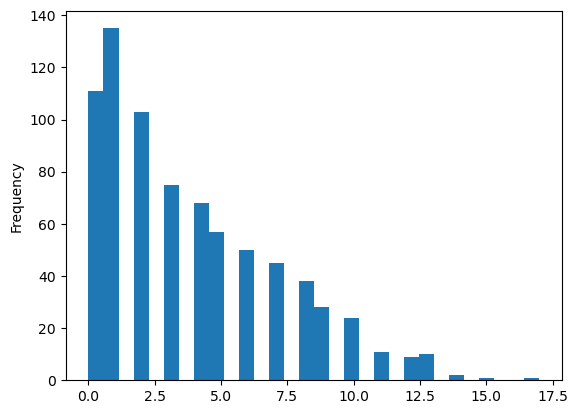

In [57]:
df1['Pregnancies'].plot.hist(bins=30)

### **변수 인사이트 정리**

## **glucose**
- 혈장 포도당 농도
- 사람 혈당이 0일 수는 없다. -> 0은 NA라고 생각
- 당뇨는 혈당이 지속적으로 높은 증상

In [8]:
# 셀 추가해서 EDA 하기
df1['Glucose'].value_counts()

Glucose
99     17
100    17
111    14
129    14
125    14
       ..
191     1
177     1
44      1
62      1
190     1
Name: count, Length: 136, dtype: int64

In [58]:
df1['Glucose'].unique()

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79,   0,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 120, 173, 170, 128, 108, 154,  57, 156, 153, 188,
       152, 104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,
        91, 165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98,
       127,  82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174,
       199,  56, 169, 149,  65, 190])

In [59]:
df1['Glucose'].value_counts().sort_index()

Glucose
0      5
44     1
56     1
57     2
61     1
      ..
195    2
196    3
197    4
198    1
199    1
Name: count, Length: 136, dtype: int64

In [11]:
df1.sort_values(by='Glucose').head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
502,6,0,68,41,0,39.0,0.727,41,1
349,5,0,80,32,0,41.0,0.346,37,1
342,1,0,68,35,0,32.0,0.389,22,0
182,1,0,74,20,23,27.7,0.299,21,0
62,5,44,62,0,0,25.0,0.587,36,0
680,2,56,56,28,45,24.2,0.332,22,0
537,0,57,60,0,0,21.7,0.735,67,0
146,9,57,80,37,0,32.8,0.096,41,0
352,3,61,82,28,0,34.4,0.243,46,0


In [12]:
df1.sort_values(by='Glucose').tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
675,6,195,70,0,0,30.9,0.328,31,1
206,8,196,76,29,280,37.5,0.605,57,1
359,1,196,76,36,249,36.5,0.875,29,1
22,7,196,90,0,0,39.8,0.451,41,1
579,2,197,70,99,0,34.7,0.575,62,1
228,4,197,70,39,744,36.7,2.329,31,0
408,8,197,74,0,0,25.9,1.191,39,1
8,2,197,70,45,543,30.5,0.158,53,1
561,0,198,66,32,274,41.3,0.502,28,1
661,1,199,76,43,0,42.9,1.394,22,1


### **변수 인사이트 정리**

## **bloodpressure**
- 혈압
- 혈압도 0일 수는 없다 -> 0은 NA라고 생각

In [13]:
# 셀 추가해서 EDA 하기
df1['BloodPressure'].value_counts()

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
52     11
54     11
75      8
92      8
65      7
85      6
94      6
48      5
96      4
44      4
100     3
106     3
98      3
110     3
55      2
108     2
104     2
46      2
30      2
122     1
95      1
102     1
61      1
24      1
38      1
40      1
114     1
Name: count, dtype: int64

In [60]:
df1['BloodPressure'].unique()

array([ 72,  66,  64,  40,  74,  50,   0,  70,  96,  92,  80,  60,  84,
        30,  88,  90,  94,  76,  82,  75,  58,  78,  68, 110,  56,  62,
        85,  86,  48,  44,  65, 108,  55, 122,  54,  52,  98, 104,  95,
        46, 102, 100,  61,  24,  38, 106, 114])

<Axes: >

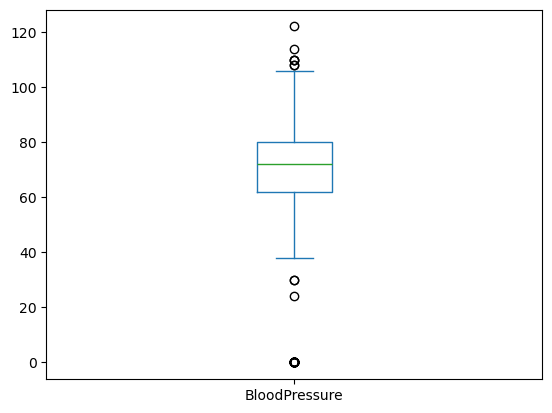

In [16]:
df1['BloodPressure'].plot.box()

### **변수 인사이트 정리**

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이란 관련이 있다.
- 0일 수 없다 -> 0은 NA라고 생각

In [27]:
# 셀 추가해서 EDA 하기
df1['SkinThickness'].value_counts()

SkinThickness
0     227
32     31
30     27
27     23
23     22
33     20
28     20
18     20
31     19
19     18
39     18
29     17
40     16
25     16
26     16
22     16
37     16
41     15
35     15
36     14
15     14
17     14
20     13
24     12
42     11
13     11
21     10
46      8
34      8
12      7
38      7
11      6
43      6
16      6
45      6
14      6
44      5
10      5
48      4
47      4
49      3
50      3
8       2
7       2
52      2
54      2
63      1
60      1
56      1
51      1
99      1
Name: count, dtype: int64

### **변수 인사이트 정리**

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다. -> 0이 나올 수 있다

In [28]:
# 셀 추가해서 EDA 하기
df1['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
73       1
171      1
255      1
52       1
112      1
Name: count, Length: 186, dtype: int64

In [32]:
df1.sort_values(by='Insulin').tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
186,8,181,68,36,495,30.1,0.615,60,1
753,0,181,88,44,510,43.3,0.222,26,1
655,2,155,52,27,540,38.7,0.240,25,1
8,2,197,70,45,543,30.5,0.158,53,1
286,5,155,84,44,545,38.7,0.619,34,0
409,1,172,68,49,579,42.4,0.702,28,1
584,8,124,76,24,600,28.7,0.687,52,1
247,0,165,90,33,680,52.3,0.427,23,0
228,4,197,70,39,744,36.7,2.329,31,0
13,1,189,60,23,846,30.1,0.398,59,1


<Axes: >

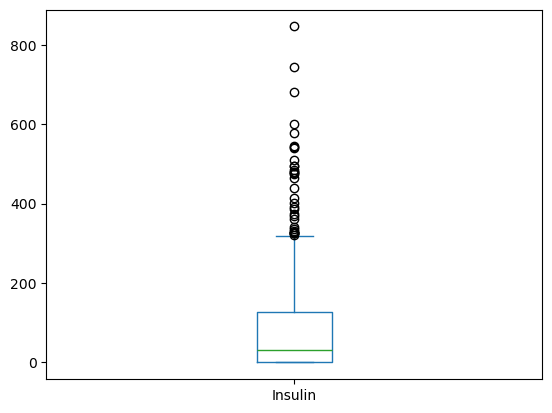

In [35]:
df1['Insulin'].plot.box()

### **변수 인사이트 정리**


* 개인적으로 0 나올 수 없다고 생각
* 2형 환자들이라도 췌장에서 최소한의 인슐린은 분비
* 또한 2형 환자들은 인슐린 주사를 맞기 때문에 오히려 수치가 높게 나타남
* 따라서 0은 결측치 처리

## **BMI**
- 0이 나올 수 없는 값

In [17]:
# 셀 추가해서  EDA 하기
df1['BMI'].value_counts()

BMI
32.0    13
31.6    12
31.2    12
0.0     11
32.4    10
        ..
36.7     1
41.8     1
42.6     1
42.8     1
46.3     1
Name: count, Length: 248, dtype: int64

In [19]:
df1.sort_values(by='BMI').head(12)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
145,0,102,75,23,0,0.0,0.572,21,0
706,10,115,0,0,0,0.0,0.261,30,1
522,6,114,0,0,0,0.0,0.189,26,0
49,7,105,0,0,0,0.0,0.305,24,0
371,0,118,64,23,89,0.0,1.731,21,0
684,5,136,82,0,0,0.0,0.640,69,0
60,2,84,0,0,0,0.0,0.304,21,0
9,8,125,96,0,0,0.0,0.232,54,1
426,0,94,0,0,0,0.0,0.256,25,0
81,2,74,0,0,0,0.0,0.102,22,0


In [25]:
df1.sort_values(by='BMI').tail(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
487,0,173,78,32,265,46.5,1.159,58,0
92,7,81,78,40,48,46.7,0.261,42,0
57,0,100,88,60,110,46.8,0.962,31,0
590,11,111,84,40,0,46.8,0.925,45,1
154,8,188,78,0,0,47.9,0.137,43,1
335,0,165,76,43,255,47.9,0.259,26,0
378,4,156,75,0,0,48.3,0.238,32,1
84,5,137,108,0,0,48.8,0.227,37,1
746,1,147,94,41,0,49.3,0.358,27,1
681,0,162,76,36,0,49.6,0.364,26,1


In [24]:
df1.iloc[177] #175cm에 205kg이 BMI 67인데 이게 가능한 수치인지...?

Pregnancies                   0.000
Glucose                     129.000
BloodPressure               110.000
SkinThickness                46.000
Insulin                     130.000
BMI                          67.100
DiabetesPedigreeFunction      0.319
Age                          26.000
Outcome                       1.000
Name: 177, dtype: float64

### **변수 인사이트 정리**

In [26]:
# bmi 0도 결측치인데 너무 크게 나온 값도 결측치를 처리해야하지 않나라고 생각함
# 근데 생각보다 촘촘하게 있어서 진짜일 가능성도 배제할 수 없을 것 같음 일단 67은 결측치 처리하는 게 맞을듯?

## **파생변수 생성 및 추가 전처리**

In [ ]:
# 셀 추가해서 하기

* SkinThickness, Insulin, BMI 세 개 변수를 종합해서 보면 비만 여부를 알 수 있을 것
* 비만인 경우 SkinThickness가 높게 나와야 하고 BMI가 높게 나와야함
* 인슐린이 안나오는 1형 당뇨병 환자들의 경우 비만이 아니라 체중 급감이 증상이기 때문에 BMI와 SkinThickness 값이 낮아야함
* 2형(인슐린 과다)가 비만과 연관

In [36]:
df2 = df1.copy()

In [41]:
print(df2.head())
print(df2.tail())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766    

In [42]:
cols_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [43]:
df2[cols_to_replace] = df2[cols_to_replace].replace(0, np.nan)

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [46]:
df2['BMI'].value_counts()

BMI
32.0    13
31.6    12
31.2    12
32.4    10
33.3    10
        ..
36.7     1
41.8     1
42.6     1
42.8     1
46.3     1
Name: count, Length: 247, dtype: int64

In [47]:
print(df2.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


* SkinThickness, Insulin, BMI 세 개 변수를 종합해서 보면 비만 여부를 알 수 있을 것
* 비만인 경우 SkinThickness가 높게 나와야 하고 BMI가 높게 나와야함
* 인슐린이 안나오는 1형 당뇨병 환자들의 경우 비만이 아니라 체중 급감이 증상이기 때문에 BMI와 SkinThickness 값이 낮아야함
* 2형(인슐린 과다)가 비만과 연관
* 이 정보들을 이용해 결측치들을 채움
* KNN Imputer 방식 : 측치가 있는 환자와 나머지 수치(예: BMI, 혈압 등)가 가장 비슷한 K명의 가상의 이웃 환자들을 찾아내서, 그 이웃들의 평균값으로 빈칸을 쏙 채워주는 방식
* 결측치 있는 정보들은 자신과 비슷한 5명 데이터들 평균으로 결측치 채움

In [61]:
from sklearn.impute import KNNImputer

In [62]:
knn_imputer = KNNImputer(n_neighbors=5)

In [63]:
obesity_cols = ['SkinThickness', 'Insulin', 'BMI', 'Glucose', 'BloodPressure']

In [64]:
imputed_data = knn_imputer.fit_transform(df1[obesity_cols])

In [65]:
df2[obesity_cols] = imputed_data

In [66]:
print("결측치 개수 확인:\n", df1.isnull().sum())

결측치 개수 확인:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# **모델링하기**

In [67]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df2[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
Y = df2['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [68]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [69]:
train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 141            5    106.0           82.0           30.0      0.0  39.5   
 597            1     89.0           24.0           19.0     25.0  27.8   
 100            1    163.0           72.0            0.0      0.0  39.0   
 338            9    152.0           78.0           34.0    171.0  34.2   
 362            5    103.0          108.0           37.0      0.0  39.2   
 ..           ...      ...            ...            ...      ...   ...   
 764            2    122.0           70.0           27.0      0.0  36.8   
 369            1    133.0          102.0           28.0    140.0  32.8   
 656            2    101.0           58.0           35.0     90.0  21.8   
 583            8    100.0           76.0            0.0      0.0  38.7   
 751            1    121.0           78.0           39.0     74.0  39.0   
 
      DiabetesPedigreeFunction  Age  
 141                     0.286   38  
 597                  

In [70]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴

In [71]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

# **각자 공부한 모델 쓰기**

# Random forest
- 특징
* decision tree를 여러 개 돌려서 나온 결과들을 취합해서 제일 많이 나온걸 선택한다고 생각하면 됨
* 분류와 회귀가 있는데 회귀 출력 변수는 숫자로 나오고 분류 출력 변수는 보통 결과가 하나의 답
* 회귀 예 : 이상 거래 금액 예측, 매출 예측
* 분류 예 : 이상 거래 탐지, 스팸 탐지, 텍스트 감성 분석(Sentiment Analysis), 환자의 위험, 패혈증 또는 암 예측

# 장점
* 회귀와 분류 문제 모두에 적합합니다. 회귀의 출력 변수는 일련의 숫자입니다(예: 인근 주택 가격). 분류 문제의 출력 변수는 보통 하나의 답입니다(예: 주택이 매도 호가 이상으로 팔릴지 또는 이하로 팔릴지).
* 배깅과 복원 샘플링 덕분에 대량의 데이터가 누락된 경우에도 결측값을 처리하고 높은 정확성을 유지합니다.
* 이 알고리즘에서는 '다수결 원칙'에 따른 출력으로 인해 모델 과적합이 거의 불가능합니다.
* 모델이 입력 변수가 수천 개인 대량의 데이터 세트를 처리할 수 있으므로 차원 축소에 좋은 도구입니다.
* 훈련 데이터 세트에서 가장 중요한 특징을 파악하는 데 해당 알고리즘을 사용할 수 있습니다.

# 단점
* 랜덤 포레스트는 결정 트리보다 성능이 뛰어나지만, XGBoost와 같은 그래디언트 부스팅 트리 앙상블보다 정확성이 낮습니다.
* 트리가 많으면 랜덤 포레스트는 XGBoost보다 느립니다.

In [33]:
# 4) 학습 수행
from import

In [ ]:
model = 
model.fit(X_train, Y_train) # 학습 수행

In [36]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율

In [37]:
Y_train_pred = model.predict(X_train)

In [38]:
Y_test_pred = model.predict(X_test)

In [39]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  1.0
검증 정확도 :  0.7135416666666666


### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성

### 특성공학(Feature Engineering)
- **특성공학** : 학습의 목적에 맞게(학습이 잘 수행될 수 있도록) 데이터를 깔끔하게 다듬는 작업
- 대표적 기법 : 
  1. Scaling & Encoding : 숫자 데이터의 스케일을 맞추거나, 문자 데이터를 숫자로 변환하여 학습에 사용
  2. Imputation : 데이터 상에 존재하는 결측값에 대해 다른 값으로 대치 (새로 들어오는 데이터가 결측일 수도 있기 때문에)
  3. Cross Validation (교차검증): 학습데이터를 여러 단계로 나누어 분할하여 학습
  4. Hyper Parameter Tuning : 학습 알고리즘 내 존재하는 수학적 구조나 학습에 발생하는 구조, 함수들을 사용자가 통제
  5. Imbalanced Data Sampling : 목표변수의 비율이 깨져있는 데이터를 맞추어 학습
  6. Feature Selection : 목표변수에 가장 영향이 있는 인자를 사용자가 지정한 만큼 선택해서 학습
  7. PCA : 데이터의 차원을 줄이거나 특성을 재구성하여 학습

- Scikit Learn에서 특성공학 기법과 학습을 동시에 수행할 수 있게 Pipe Line 구성하여 학습을 수행

In [14]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [ ]:
# 파이프라인 구조 설계
#스케일링 하고 싶으면 StandardScaler() 사용

model_pipe = make_pipeline( , )
model_pipe

In [25]:
from sklearn.model_selection import GridSearchCV

#### **공부한 모델의 하이퍼파라미터**

- 여기에 정리하기
- ex: 하이퍼 파라미터의 종류는 ~~가 있고, 값을 키우면 과적합이 발생할 수 있다.


In [26]:
# 하이퍼파라미터 튜닝 및 교차검증
hyperparam = { , }

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3,
                          scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

In [ ]:
best_model1

In [27]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [18]:
from sklearn.metrics import classification_report

In [29]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       379
           1       0.81      0.75      0.78       197

    accuracy                           0.85       576
   macro avg       0.84      0.83      0.83       576
weighted avg       0.85      0.85      0.85       576



In [30]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       121
           1       0.62      0.56      0.59        71

    accuracy                           0.71       192
   macro avg       0.69      0.68      0.69       192
weighted avg       0.71      0.71      0.71       192



# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.  